# 2단계 — ConvNeXt 분류기 학습 (SOC-50)

## 이 노트북의 역할
분류기 5종 비교의 세 번째 모델 — **ConvNeXt-Tiny** (CVPR 2022).
Vision Transformer의 설계 원리를 CNN에 접목한 최신 합성곱 신경망으로,
"SAR 전용 사전학습 없이 범용(ImageNet) 사전학습만으로 어디까지 가능한가"를 보여주는 대표 주자.

## 비교 기준
- 논문(ATRBench) ConvNeXt SOC-50: **81.6%** (8개 모델 중 2위)
- 우리 결과: ResNet18 80.49% / SARATR-X 89.30%
- 관전 포인트: ImageNet 사전학습 CNN의 상한선이 SAR 사전학습(SARATR-X)에 얼마나 못 미치는가

## 구성
**resnet18.ipynb와 모델 정의 셀(셀 4)만 다름** — 데이터/증강/학습/평가 전부 동일 (공정 비교).
- ResNet과의 차이: 분류층 위치가 `model.fc`가 아니라 `model.classifier[2]`
- ConvNeXt-Tiny 파라미터 ~28M (ResNet18의 2.5배) → T4에서 에폭당 ~1.5분, 30에폭 ~45분

## 사전 준비
- 드라이브 `MyDrive/ATRNet-STAR/soc50.tar`
- 런타임 → T4 GPU (A100이면 ~15분)

In [ ]:
# 1. GPU 확인 + 드라이브 마운트
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음 — 런타임 유형 변경!")

from google.colab import drive
drive.mount('/content/drive')

GPU: Tesla T4
Mounted at /content/drive


In [ ]:
# 2. 데이터를 코랩 로컬로 복사 (이미 있으면 건너뜀)
import os

SETTING  = "SOC_50classes"
TAR_PATH = "/content/drive/MyDrive/ATRNet-STAR/soc50.tar"
DATA_DIR = f"/content/{SETTING}"

if not os.path.exists(DATA_DIR):
    !cp "{TAR_PATH}" /content/soc50.tar
    !tar -xf /content/soc50.tar -C /content/ && rm /content/soc50.tar

!ls "{DATA_DIR}"

test  train


## 3. 데이터셋 / 데이터로더

ResNet18 노트북과 **완전히 동일한 확정 레시피**:
- train: Resize 128 → Grayscale 3ch → Flip + Affine(10°, 0.1) → ToTensor → RandomErasing(0.3)
- test: 증강 없음 (Resize + Grayscale + ToTensor)
- 증강의 효과는 ResNet18 실험에서 검증됨 (55.47% → 80.49%)

In [ ]:
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR  = os.path.join(DATA_DIR, "test")

# ----- train: 증강 포함 (확정 레시피) -----
train_transform = T.Compose([
    T.Resize((128, 128)),
    T.Grayscale(num_output_channels=3),
    T.RandomHorizontalFlip(),                          # 좌우 반전
    T.RandomAffine(degrees=10, translate=(0.1, 0.1)),  # 회전/이동
    T.ToTensor(),
    T.RandomErasing(p=0.3),                            # 부분 가림
])
# ----- test: 증강 없음 -----
test_transform = T.Compose([
    T.Resize((128, 128)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
])

train_ds = ImageFolder(TRAIN_DIR, transform=train_transform)
test_ds  = ImageFolder(TEST_DIR,  transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

NUM_CLASSES = len(train_ds.classes)
print(f"클래스 수: {NUM_CLASSES} / train {len(train_ds)} / test {len(test_ds)}")

클래스 수: 50 / train 18071 / test 17603


## 4. 모델 — ConvNeXt-Tiny (ImageNet 사전학습)  ← ResNet 노트북과 다른 유일한 셀

- `convnext_tiny(weights=DEFAULT)`: ImageNet-1k 사전학습 가중치
- **분류층 위치 주의**: ConvNeXt는 `model.classifier`가 [LayerNorm, Flatten, Linear] 시퀀스 —
  마지막 요소 `classifier[2]`(Linear)만 50클래스로 교체
- 손실/옵티마이저/스케줄러는 확정 레시피 그대로 (label smoothing 0.1, AdamW 1e-4, cosine)

In [ ]:
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

MODEL_NAME = "convnext_soc50"     # 체크포인트/결과 파일명에 사용
EPOCHS = 30
LR = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
# 분류층 교체: classifier = [LayerNorm2d, Flatten, Linear] → 마지막 Linear만 50클래스로
model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)                             # 확정 레시피
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

SAVE_DIR = "/content/drive/MyDrive/ATRNet-STAR"
os.makedirs(f"{SAVE_DIR}/checkpoints", exist_ok=True)
os.makedirs(f"{SAVE_DIR}/results", exist_ok=True)
CKPT_PATH = f"{SAVE_DIR}/checkpoints/{MODEL_NAME}_ckpt.pth"

print(f"{MODEL_NAME} 파라미터: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 173MB/s]


convnext_soc50 파라미터: 27.9M


## 5. 학습 루프

ResNet18 노트북과 동일 — 에폭마다 드라이브 체크포인트, 끊기면 재실행으로 이어 학습.
(처음부터 다시 하려면 드라이브의 `convnext_soc50_ckpt.pth` 삭제 후 실행)

In [ ]:
import time

start_epoch, history = 0, []
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    start_epoch, history = ckpt["epoch"] + 1, ckpt["history"]
    print(f"체크포인트 발견 → 에폭 {start_epoch + 1}부터 재개")

t0 = time.time()
for epoch in range(start_epoch, EPOCHS):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(x)            # 순전파
        loss = criterion(out, y)  # 손실 (label smoothing 포함)
        loss.backward()           # 역전파
        optimizer.step()          # 가중치 갱신
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        n += x.size(0)
    scheduler.step()

    history.append({"epoch": epoch, "train_loss": total_loss/n, "train_acc": correct/n})
    print(f"Epoch {epoch+1}/{EPOCHS} | loss {total_loss/n:.4f} | acc {correct/n:.4f} "
          f"| 누적 {(time.time()-t0)/60:.1f}분")

    torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(), "epoch": epoch, "history": history},
               CKPT_PATH)

print("학습 완료")

체크포인트 발견 → 에폭 31부터 재개
학습 완료


## 6. 평가 + 결과 저장

동일 형식 json 저장 → 비교 노트북 호환. 비교: 논문 ConvNeXt 81.6% / 우리 ResNet18 80.49% / SARATR-X 89.30%

In [ ]:
import json
import numpy as np

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device, non_blocking=True))
        y_pred.extend(out.argmax(1).cpu().tolist())
        y_true.extend(y.tolist())

y_true, y_pred = np.array(y_true), np.array(y_pred)
overall_acc = float((y_true == y_pred).mean())
per_class_acc = {cls: float((y_pred[y_true == i] == i).mean())
                 for i, cls in enumerate(test_ds.classes) if (y_true == i).sum() > 0}

print(f"Overall Accuracy: {overall_acc*100:.2f}%")
print("(비교: 논문 ConvNeXt 81.6% / 우리 ResNet18 80.49% / SARATR-X 89.30%)")

result = {"model": MODEL_NAME, "setting": "SOC-50", "epochs": EPOCHS, "lr": LR,
          "overall_acc": overall_acc, "per_class_acc": per_class_acc,
          "classes": test_ds.classes, "y_true": y_true.tolist(), "y_pred": y_pred.tolist(),
          "history": history}
with open(f"{SAVE_DIR}/results/{MODEL_NAME}.json", "w") as f:
    json.dump(result, f)

torch.save(model.state_dict(), f"{SAVE_DIR}/checkpoints/{MODEL_NAME}_final.pth")
print("저장 완료:", f"results/{MODEL_NAME}.json + checkpoints/{MODEL_NAME}_final.pth")

Overall Accuracy: 87.75%
(비교: 논문 ConvNeXt 81.6% / 우리 ResNet18 80.49% / SARATR-X 89.30%)
저장 완료: results/convnext_soc50.json + checkpoints/convnext_soc50_final.pth


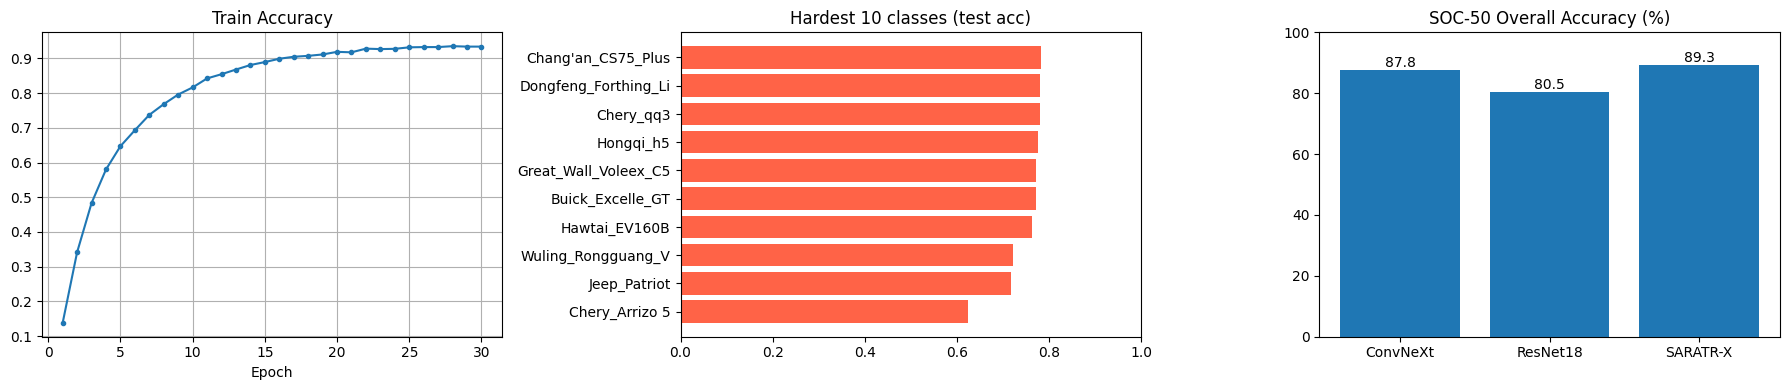

In [ ]:
# 7. 결과 시각화 — 학습 곡선 + 어려운 클래스 + 모델 비교
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot([h["epoch"]+1 for h in history], [h["train_acc"] for h in history], marker="o", ms=3)
axes[0].set_title("Train Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].grid(True)

sorted_cls = sorted(per_class_acc.items(), key=lambda x: x[1])
axes[1].barh([c[:20] for c, _ in sorted_cls[:10]], [a for _, a in sorted_cls[:10]], color="tomato")
axes[1].set_title("Hardest 10 classes (test acc)"); axes[1].set_xlim(0, 1)

# 모델 비교 (드라이브의 결과 json 자동 수집)
comp = {"ConvNeXt": overall_acc}
for name, fname in [("ResNet18", "resnet18_soc50"), ("SARATR-X", "saratrx_soc50")]:
    try:
        with open(f"{SAVE_DIR}/results/{fname}.json") as f:
            comp[name] = json.load(f)["overall_acc"]
    except FileNotFoundError:
        pass
names, accs = list(comp.keys()), [v*100 for v in comp.values()]
bars = axes[2].bar(names, accs)
axes[2].set_title("SOC-50 Overall Accuracy (%)"); axes[2].set_ylim(0, 100)
for b, a in zip(bars, accs):
    axes[2].text(b.get_x() + b.get_width()/2, a + 1, f"{a:.1f}", ha="center")

plt.tight_layout(); plt.show()

## 다음 단계

1. `results/convnext_soc50.json` 생성 확인
2. 파이프라인 평가가 필요하면 `pipeline/soc50/single_convnext.ipynb` 셀 3의 분류기 블록을 ConvNeXt로 교체:
```python
from torchvision.models import convnext_tiny
classifier = convnext_tiny()
classifier.classifier[2] = nn.Linear(classifier.classifier[2].in_features, NUM_CLASSES)
classifier.load_state_dict(torch.load(f"{SAVE_DIR}/checkpoints/convnext_soc50_final.pth", map_location=device))
classifier = classifier.to(device).eval()
# cls_transform은 Resize (128, 128) 그대로 (ResNet과 동일 — 224 아님!)
```
3. 남은 모델: ResNet34 (이 노트북에서 셀 4만 교체), HDANet (공식 repo)